# Notebook 00: Load & Assign SRK S-Allele Genotype Data

This notebook loads SRK (S-locus Receptor Kinase) **S-allele** data for **slickspot peppergrass**
(*Lepidium papilliferum*), assigns tetraploid genotypes from allele copy-count matrices,
and exports population data for downstream analysis.

## Key Differences from Protein-Based Approach

| Feature | Old (protein-based) | New (S-allele-based) |
|---|---|---|
| Genotype matrix | Binary presence/absence (`SRK_individual_genotypes.tsv`) | Copy-count matrix (`SRK_individual_allele_genotypes.tsv`) |
| Allele resolution | Required `SRK_individual_protein_table.tsv` read counts for AABC | Count matrix directly encodes copy counts per allele bin |
| Allele identifiers | `SRK_protein_001` … `SRK_protein_094` | `Allele_002` … `Allele_050` |
| Genotype patterns | AAAA, AABB, AABC, ABCD | AAAA, AABB, **AAAB**, AABC |

## Input Files

- `SRK_individual_allele_genotypes.tsv` — count matrix (individuals × allele bins; values = distinct protein count per bin)
- `SRK_individual_zygosity.tsv` — zygosity table with `Genotype` pattern and `Allele_composition`
- `sampling_metadata.csv` — population/library metadata
- `SRK_individual_allele_table.tsv` — long-format allele table (optional, used for cross-validation)


In [1]:
import os
import re
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ---------------------------------------------------------------------------
# Configuration — set SALLELES_DIR to the folder containing the S-allele files
# Default: data/salleles/  (copy pipeline outputs there, or adjust path below)
# ---------------------------------------------------------------------------
DATA_DIR = os.path.join("..", "data")
SALLELES_DIR = os.path.join(DATA_DIR, "salleles")

os.makedirs(SALLELES_DIR, exist_ok=True)
print(f"S-allele data directory: {os.path.abspath(SALLELES_DIR)}")
print("Place the following pipeline output files in that directory:")
print("  SRK_individual_allele_genotypes.tsv")
print("  SRK_individual_zygosity.tsv")
print("  SRK_individual_allele_table.tsv  (optional)")
print("  sampling_metadata.csv")
print("Imports loaded.")

S-allele data directory: /Users/sven/Documents/Current_projects/SRK_bioinformatics/Canu_amplicon/modeling/data/salleles
Place the following pipeline output files in that directory:
  SRK_individual_allele_genotypes.tsv
  SRK_individual_zygosity.tsv
  SRK_individual_allele_table.tsv  (optional)
  sampling_metadata.csv
Imports loaded.


## 1. Load Data Files

Load the three required data files (`encoding='utf-8-sig'` handles BOM from Excel-touched TSVs).

In [2]:
# --- Load required data files ---
zygosity_df  = pd.read_csv(os.path.join(SALLELES_DIR, "SRK_individual_zygosity.tsv"),
                           sep="\t", encoding="utf-8-sig")
genotypes_df = pd.read_csv(os.path.join(SALLELES_DIR, "SRK_individual_allele_genotypes.tsv"),
                           sep="\t", encoding="utf-8-sig")
metadata_df  = pd.read_csv(os.path.join(SALLELES_DIR, "sampling_metadata.csv"),
                           encoding="utf-8-sig")

# Optional: allele table for cross-validation
allele_table_path = os.path.join(SALLELES_DIR, "SRK_individual_allele_table.tsv")
if os.path.exists(allele_table_path):
    allele_table = pd.read_csv(allele_table_path, sep="\t", encoding="utf-8-sig")
    print(f"Allele table loaded: {allele_table.shape[0]} rows")
else:
    allele_table = None
    print("Allele table not found — skipping cross-validation against long-format table.")

# Identify allele columns
allele_columns = [c for c in genotypes_df.columns if c.startswith("Allele_")]

print("\nFile shapes:")
print(f"  Zygosity:         {zygosity_df.shape[0]} individuals x {zygosity_df.shape[1]} columns")
print(f"  Allele genotypes: {genotypes_df.shape[0]} individuals x {len(allele_columns)} allele bins")
print(f"  Metadata:         {metadata_df.shape[0]} samples")
print(f"\nZygosity columns: {list(zygosity_df.columns)}")
print(f"\nGenotype pattern distribution:")
print(zygosity_df["Genotype"].value_counts().to_string())

Allele table loaded: 398 rows

File shapes:
  Zygosity:         189 individuals x 6 columns
  Allele genotypes: 189 individuals x 47 allele bins
  Metadata:         217 samples

Zygosity columns: ['Individual', 'N_distinct_alleles', 'N_total_proteins', 'Zygosity', 'Genotype', 'Allele_composition']

Genotype pattern distribution:
Genotype
AAAA    105
AABB     40
AAAB     39
AABC      5


## 2. Data Overview & Cross-Validation

Verify internal consistency: the sum of allele counts per individual in the count matrix
should match `N_total_proteins` in the zygosity file.

In [3]:
# --- Cross-validate: row sums in count matrix should equal N_total_proteins ---
count_sums = genotypes_df.set_index("Individual")[allele_columns].sum(axis=1).astype(int)
merged_check = zygosity_df.set_index("Individual")[["N_total_proteins"]].join(
    count_sums.rename("matrix_sum")
)
mismatches = merged_check[merged_check["N_total_proteins"] != merged_check["matrix_sum"]]
if len(mismatches) == 0:
    print(f"Cross-validation PASSED: N_total_proteins matches matrix row sums for all "
          f"{len(merged_check)} individuals.")
else:
    print(f"WARNING: {len(mismatches)} mismatch(es) found:")
    print(mismatches.to_string())

# --- N_distinct_alleles cross-check ---
n_distinct = (genotypes_df.set_index("Individual")[allele_columns] > 0).sum(axis=1).astype(int)
merged_distinct = zygosity_df.set_index("Individual")[["N_distinct_alleles"]].join(
    n_distinct.rename("matrix_distinct")
)
dist_mismatches = merged_distinct[
    merged_distinct["N_distinct_alleles"] != merged_distinct["matrix_distinct"]
]
if len(dist_mismatches) == 0:
    print(f"N_distinct_alleles cross-validation PASSED.")
else:
    print(f"WARNING: {len(dist_mismatches)} N_distinct_alleles mismatch(es):")
    print(dist_mismatches.to_string())

Cross-validation PASSED: N_total_proteins matches matrix row sums for all 189 individuals.
N_distinct_alleles cross-validation PASSED.


## 3. Filter to Ingroup Individuals

The metadata contains an `Ingroup` flag (1 = *L. papilliferum*, 0 = outgroup species).
Exclude outgroup samples and any individual lacking metadata.

In [4]:
# --- Identify exclusions ---
zyg_individuals  = set(zygosity_df["Individual"])
meta_individuals = set(metadata_df["SampleID"])

no_metadata  = zyg_individuals - meta_individuals
outgroup_ids = set(metadata_df[metadata_df["Ingroup"] == 0]["SampleID"])
outgroup_with_data = outgroup_ids & zyg_individuals
exclude_ids = outgroup_with_data | no_metadata

print(f"Excluded: {len(outgroup_with_data)} outgroup + {len(no_metadata)} no-metadata "
      f"= {len(exclude_ids)} total")
if no_metadata:
    print(f"  No-metadata individuals: {no_metadata}")

# --- Filter data frames ---
zygosity_filtered = zygosity_df[~zygosity_df["Individual"].isin(exclude_ids)].copy()
genotypes_filtered = genotypes_df[~genotypes_df["Individual"].isin(exclude_ids)].copy()

print(f"\nIngroup individuals retained: {len(zygosity_filtered)}")
print("Genotype distribution (ingroup):")
print(zygosity_filtered["Genotype"].value_counts().to_string())

Excluded: 0 outgroup + 0 no-metadata = 0 total

Ingroup individuals retained: 189
Genotype distribution (ingroup):
Genotype
AAAA    105
AABB     40
AAAB     39
AABC      5


## 4. Assign Tetraploid Genotypes

For each individual, combine the **zygosity pattern** with the **allele copy counts** from the
count matrix to build the 4-allele genotype tuple. No read-depth resolution is needed —
the copy counts in the allele genotype matrix directly encode allele dosage.

### Assignment Logic

| Pattern | N distinct alleles | Count matrix signature | Genotype tuple |
|---|---|---|---|
| **AAAA** | 1 | single allele (any count) | (A, A, A, A) |
| **AABB** | 2 | both alleles equal count | (A, A, B, B) |
| **AAAB** | 2 | one allele count > other | (A, A, A, B) dominant = higher count |
| **AABC** | 3 | one allele count > 1; two singletons | (A, A, B, C) doubled = higher count |
| **ABCD** | 4 | all alleles count = 1 | (A, B, C, D) |


In [5]:
def assign_genotype(individual, genotype_pattern, allele_counts):
    """Assign a tetraploid genotype from zygosity pattern and allele copy counts.

    Parameters
    ----------
    individual : str
        Individual identifier.
    genotype_pattern : str
        One of 'AAAA', 'AABB', 'AAAB', 'AABC', 'ABCD'.
    allele_counts : dict[str, int]
        Copy counts per allele bin (only non-zero alleles from count matrix).

    Returns
    -------
    tuple[str, ...]
        Sorted 4-element tuple of allele bin names.
    str
        Assignment method description.
    """
    alleles = sorted(allele_counts.keys())
    n = len(alleles)

    if genotype_pattern == "AAAA":
        if n != 1:
            raise ValueError(f"{individual}: AAAA but {n} alleles detected")
        a = alleles[0]
        return tuple([a] * 4), "homozygous_4x"

    elif genotype_pattern == "AABB":
        if n != 2:
            raise ValueError(f"{individual}: AABB but {n} alleles detected")
        a, b = alleles[0], alleles[1]
        return tuple(sorted([a, a, b, b])), "heterozygous_2x2"

    elif genotype_pattern == "AAAB":
        if n != 2:
            raise ValueError(f"{individual}: AAAB but {n} alleles detected")
        # Allele with higher count is the dominant (tripled) allele
        dominant = max(alleles, key=lambda x: (allele_counts[x], x))
        minor = [x for x in alleles if x != dominant][0]
        return tuple(sorted([dominant, dominant, dominant, minor])), "heterozygous_3x1"

    elif genotype_pattern == "AABC":
        if n != 3:
            raise ValueError(f"{individual}: AABC but {n} alleles detected")
        # Allele with highest count is doubled; remaining two are singletons
        doubled = max(alleles, key=lambda x: (allele_counts[x], x))
        singles = sorted([x for x in alleles if x != doubled])
        return tuple(sorted([doubled, doubled] + singles)), "heterozygous_2x1x1"

    elif genotype_pattern == "ABCD":
        if n != 4:
            raise ValueError(f"{individual}: ABCD but {n} alleles detected")
        return tuple(sorted(alleles)), "heterozygous_1x4"

    else:
        raise ValueError(f"{individual}: unknown genotype pattern '{genotype_pattern}'")


# --- Apply assignment to all ingroup individuals ---
geno_indexed = genotypes_filtered.set_index("Individual")[allele_columns]
zyg_indexed  = zygosity_filtered.set_index("Individual")

records = []
for ind in zygosity_filtered["Individual"]:
    pattern = zyg_indexed.loc[ind, "Genotype"]
    row_counts = geno_indexed.loc[ind]
    ac = {col: int(row_counts[col]) for col in allele_columns if row_counts[col] > 0}

    genotype, method = assign_genotype(ind, pattern, ac)
    records.append({
        "individual":       ind,
        "genotype_pattern": pattern,
        "detected_alleles": list(ac.keys()),
        "allele_counts":    ac,
        "genotype":         genotype,
        "method":           method,
    })

assignments_df = pd.DataFrame(records)
print(f"Assigned genotypes for {len(assignments_df)} individuals.")
print("Pattern distribution:")
print(assignments_df["genotype_pattern"].value_counts().to_string())

Assigned genotypes for 189 individuals.
Pattern distribution:
genotype_pattern
AAAA    105
AABB     40
AAAB     39
AABC      5


## 5. Worked Examples

Show genotype assignment step-by-step for one individual from each genotype pattern.

In [6]:
for pattern in ["AAAA", "AABB", "AAAB", "AABC", "ABCD"]:
    subset = assignments_df[assignments_df["genotype_pattern"] == pattern]
    if len(subset) == 0:
        print(f"=== {pattern}: no examples in this dataset ===\n")
        continue
    example = subset.iloc[0]
    ind = example["individual"]
    print(f"=== {pattern}: {ind} ===")
    print(f"  Detected alleles + counts: {example['allele_counts']}")
    print(f"  Assigned genotype:         {example['genotype']}")
    print(f"  Method:                    {example['method']}")
    allele_comp = zyg_indexed.loc[ind, "Allele_composition"]
    print(f"  Allele_composition (ref):  {allele_comp}")
    print()

=== AAAA: Library001_barcode03 ===
  Detected alleles + counts: {'Allele_024': 1}
  Assigned genotype:         ('Allele_024', 'Allele_024', 'Allele_024', 'Allele_024')
  Method:                    homozygous_4x
  Allele_composition (ref):  Allele_024(1)

=== AABB: Library001_barcode09 ===
  Detected alleles + counts: {'Allele_009': 1, 'Allele_048': 1}
  Assigned genotype:         ('Allele_009', 'Allele_009', 'Allele_048', 'Allele_048')
  Method:                    heterozygous_2x2
  Allele_composition (ref):  Allele_009(1)+Allele_048(1)

=== AAAB: Library001_barcode02 ===
  Detected alleles + counts: {'Allele_007': 1, 'Allele_048': 3}
  Assigned genotype:         ('Allele_007', 'Allele_048', 'Allele_048', 'Allele_048')
  Method:                    heterozygous_3x1
  Allele_composition (ref):  Allele_007(1)+Allele_048(3)

=== AABC: Library002_barcode43 ===
  Detected alleles + counts: {'Allele_011': 1, 'Allele_032': 1, 'Allele_048': 2}
  Assigned genotype:         ('Allele_011', 'Allele

### All AABC and AAAB Individuals (Detail)

AABC requires identifying the doubled allele from the count matrix.
AAAB identifies the tripled (dominant) allele similarly.

In [7]:
for pattern in ["AABC", "AAAB"]:
    subset = assignments_df[assignments_df["genotype_pattern"] == pattern]
    print(f"{pattern} individuals: {len(subset)}\n")
    for _, row in subset.iterrows():
        ind = row["individual"]
        allele_comp = zyg_indexed.loc[ind, "Allele_composition"]
        print(f"  {ind}")
        print(f"    Counts:            {row['allele_counts']}")
        print(f"    Assigned genotype: {row['genotype']}")
        print(f"    Allele_composition (ref): {allele_comp}")
    print()

AABC individuals: 5

  Library002_barcode43
    Counts:            {'Allele_011': 1, 'Allele_032': 1, 'Allele_048': 2}
    Assigned genotype: ('Allele_011', 'Allele_032', 'Allele_048', 'Allele_048')
    Allele_composition (ref): Allele_011(1)+Allele_032(1)+Allele_048(2)
  Library002_barcode51
    Counts:            {'Allele_010': 2, 'Allele_023': 1, 'Allele_045': 1}
    Assigned genotype: ('Allele_010', 'Allele_010', 'Allele_023', 'Allele_045')
    Allele_composition (ref): Allele_023(1)+Allele_045(1)+Allele_010(2)
  Library007_barcode82
    Counts:            {'Allele_028': 1, 'Allele_029': 1, 'Allele_034': 2}
    Assigned genotype: ('Allele_028', 'Allele_029', 'Allele_034', 'Allele_034')
    Allele_composition (ref): Allele_028(1)+Allele_029(1)+Allele_034(2)
  Library007_barcode86
    Counts:            {'Allele_045': 1, 'Allele_046': 2, 'Allele_048': 1}
    Assigned genotype: ('Allele_045', 'Allele_046', 'Allele_046', 'Allele_048')
    Allele_composition (ref): Allele_045(1)+Allele_

## 6. Validation

Verify all assigned genotypes have exactly 4 elements, are sorted, and contain valid allele names.

In [8]:
errors = []

for _, row in assignments_df.iterrows():
    g   = row["genotype"]
    ind = row["individual"]

    if len(g) != 4:
        errors.append(f"{ind}: genotype has {len(g)} elements, expected 4")
    if g != tuple(sorted(g)):
        errors.append(f"{ind}: genotype {g} is not sorted")
    for a in g:
        if a not in allele_columns:
            errors.append(f"{ind}: allele '{a}' not in allele columns")

if errors:
    print(f"VALIDATION FAILED: {len(errors)} error(s)")
    for e in errors:
        print(f"  {e}")
else:
    print(f"VALIDATION PASSED: all {len(assignments_df)} genotypes are valid 4-element sorted tuples.")

VALIDATION PASSED: all 189 genotypes are valid 4-element sorted tuples.


## 7. Allele Name-to-Integer Mapping

Map allele bin names (e.g., `Allele_044`) to integer IDs for computational efficiency
in downstream notebooks.

In [9]:
# Sort allele names and assign integer IDs 1..N
sorted_allele_names = sorted(allele_columns)
name_to_id = {name: i + 1 for i, name in enumerate(sorted_allele_names)}
id_to_name = {v: k for k, v in name_to_id.items()}

allele_pool = sorted(name_to_id.values())  # [1, 2, ..., N]

print(f"Allele pool: {len(allele_pool)} allele bins (IDs {allele_pool[0]} to {allele_pool[-1]})")
print(f"\nFirst 5 mappings:")
for name in sorted_allele_names[:5]:
    print(f"  {name} -> {name_to_id[name]}")
print(f"\nLast 5 mappings:")
for name in sorted_allele_names[-5:]:
    print(f"  {name} -> {name_to_id[name]}")

# Convert genotype tuples to integer IDs
population_genotypes = []
for _, row in assignments_df.iterrows():
    int_genotype = tuple(sorted(name_to_id[a] for a in row["genotype"]))
    population_genotypes.append(int_genotype)

print(f"\nSample integer genotypes (first 5):")
for i in range(min(5, len(population_genotypes))):
    ind = assignments_df.iloc[i]["individual"]
    print(f"  {ind}: {population_genotypes[i]}")

Allele pool: 47 allele bins (IDs 1 to 47)

First 5 mappings:
  Allele_002 -> 1
  Allele_007 -> 2
  Allele_008 -> 3
  Allele_009 -> 4
  Allele_010 -> 5

Last 5 mappings:
  Allele_051 -> 43
  Allele_052 -> 44
  Allele_053 -> 45
  Allele_054 -> 46
  Allele_055 -> 47

Sample integer genotypes (first 5):
  Library001_barcode02: (2, 40, 40, 40)
  Library001_barcode03: (17, 17, 17, 17)
  Library001_barcode04: (13, 13, 13, 13)
  Library001_barcode05: (17, 17, 17, 17)
  Library001_barcode06: (6, 6, 6, 6)


## 8. Population Grouping

Individuals are grouped by the **Pop** field from the metadata (not by Library).
The Pop field represents biological populations / element occurrences.

In [10]:
individual_names = assignments_df["individual"].tolist()

# --- Join population info to assignments ---
meta_lookup = metadata_df.set_index("SampleID")[["Pop", "EO_w_sub", "Library", "Ingroup"]]
pop_map = {}
for ind in individual_names:
    pop_map[ind] = str(meta_lookup.loc[ind, "Pop"]) if ind in meta_lookup.index else "unknown"

assignments_df["pop"] = assignments_df["individual"].map(pop_map)

# --- Population size distribution ---
pop_counts = assignments_df["pop"].value_counts().sort_values(ascending=False)
print(f"Populations: {len(pop_counts)}")
print(f"Major populations (>= 5 individuals): {(pop_counts >= 5).sum()}")
print(f"\nAll populations:")
for pop, cnt in pop_counts.items():
    flag = " *** MAJOR" if cnt >= 5 else ""
    print(f"  Pop {pop}: {cnt} individuals{flag}")

# --- Group genotypes and names by population ---
pop_populations = {}  # Pop -> list of int genotype tuples
pop_individuals = {}  # Pop -> list of individual names
for i, (_, row) in enumerate(assignments_df.iterrows()):
    p = row["pop"]
    pop_populations.setdefault(p, []).append(population_genotypes[i])
    pop_individuals.setdefault(p, []).append(row["individual"])

Populations: 26
Major populations (>= 5 individuals): 5

All populations:
  Pop 70: 40 individuals *** MAJOR
  Pop 25: 32 individuals *** MAJOR
  Pop 67: 32 individuals *** MAJOR
  Pop 27: 29 individuals *** MAJOR
  Pop 76: 25 individuals *** MAJOR
  Pop 68: 3 individuals
  Pop 118: 3 individuals
  Pop 18: 3 individuals
  Pop 8: 2 individuals
  Pop 52: 2 individuals
  Pop 96-16: 2 individuals
  Pop 15: 2 individuals
  Pop 405: 1 individuals
  Pop 702-3: 1 individuals
  Pop 712-5: 1 individuals
  Pop 38: 1 individuals
  Pop 61: 1 individuals
  Pop 709: 1 individuals
  Pop 29: 1 individuals
  Pop 48: 1 individuals
  Pop 26-3: 1 individuals
  Pop 704: 1 individuals
  Pop 84-2: 1 individuals
  Pop 702-24: 1 individuals
  Pop 24: 1 individuals
  Pop 715-1: 1 individuals


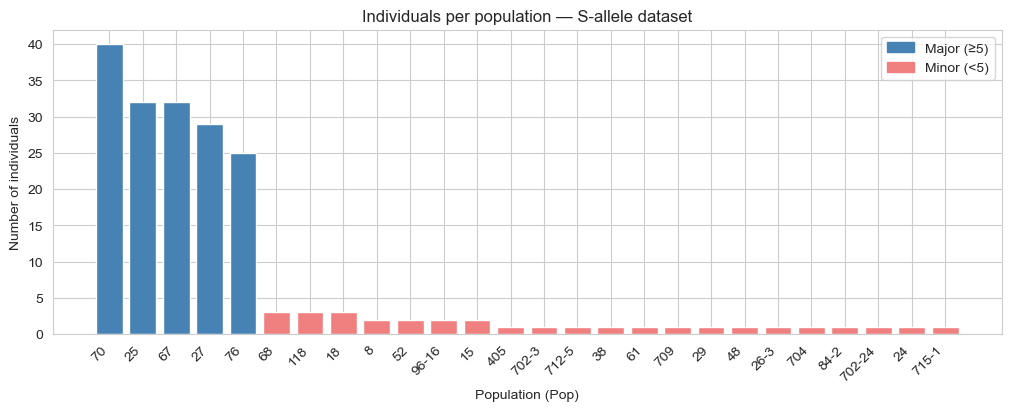

In [11]:
# --- Visualize population sizes ---
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
pops_sorted = pop_counts.index.tolist()
colors = ["steelblue" if c >= 5 else "lightcoral" for c in pop_counts.values]
ax.bar(range(len(pops_sorted)), pop_counts.values, color=colors, edgecolor="white")
ax.set_xticks(range(len(pops_sorted)))
ax.set_xticklabels(pops_sorted, rotation=45, ha="right")
ax.set_xlabel("Population (Pop)")
ax.set_ylabel("Number of individuals")
ax.set_title("Individuals per population — S-allele dataset")
import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color="steelblue", label="Major (≥5)"),
    mpatches.Patch(color="lightcoral", label="Minor (<5)"),
])
plt.show()

## 9. EDA: Allele Prevalence

How many individuals carry each S-allele bin?
This informs allele rarity and crossing strategy.

In [12]:
# Allele prevalence (presence/absence) across ingroup individuals
ingroup_geno = genotypes_filtered.set_index("Individual")[allele_columns]
allele_prevalence = (ingroup_geno > 0).sum(axis=0).astype(int).sort_values(ascending=False)

detected_alleles = allele_prevalence[allele_prevalence > 0]
n_singletons = int((detected_alleles == 1).sum())

print(f"Total allele columns in matrix: {len(allele_columns)}")
print(f"Allele bins detected in ingroup: {len(detected_alleles)}")
print(f"Singletons (1 individual): {n_singletons}")
print(f"Core alleles (2+ individuals): {len(detected_alleles) - n_singletons}")
print(f"\nTop 10 most prevalent alleles:")
print(detected_alleles.head(10).to_string())

Total allele columns in matrix: 47
Allele bins detected in ingroup: 47
Singletons (1 individual): 20
Core alleles (2+ individuals): 27

Top 10 most prevalent alleles:
Allele_048    66
Allele_044    64
Allele_045    15
Allele_022    11
Allele_043    11
Allele_016    10
Allele_020     7
Allele_028     6
Allele_030     5
Allele_049     5


## 10. Allele Frequencies

Compute allele frequencies from assigned tetraploid genotypes (4 copies per individual).
Compare to the NFDS equilibrium target (equal frequency for all alleles).

Total allele bins (integer IDs): 47
Detected allele bins (freq > 0): 47
NFDS equilibrium frequency:      0.0213 (1/47)


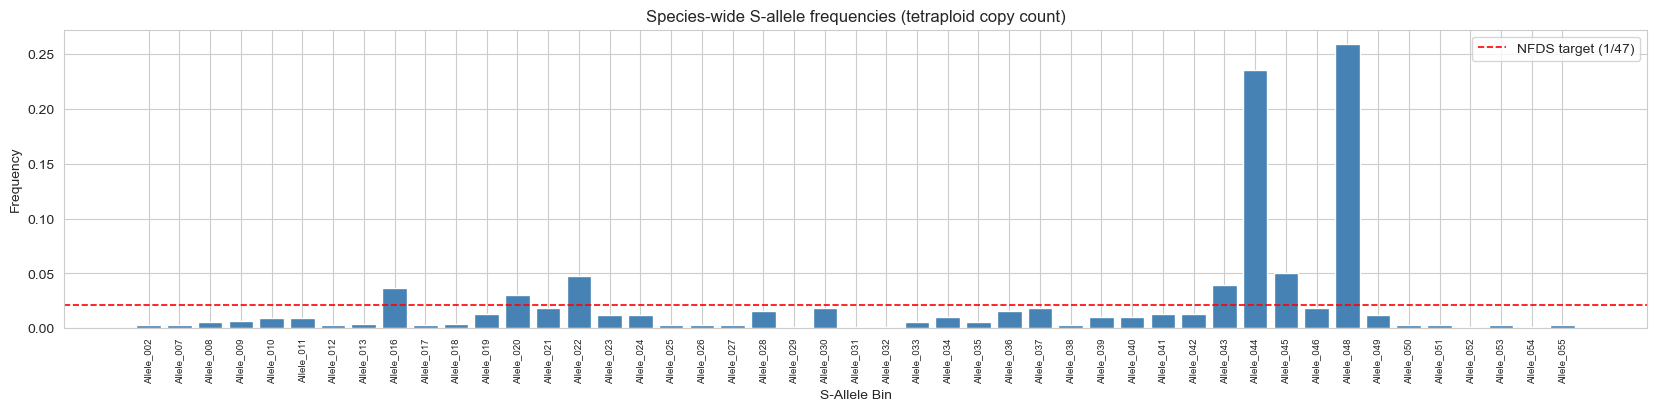

In [13]:
def allele_frequencies(population, allele_pool=None):
    """Compute allele frequencies from a list of genotype tuples."""
    counts = Counter()
    total = 0
    for genotype in population:
        for allele in genotype:
            counts[allele] += 1
            total += 1
    freqs = {a: counts[a] / total for a in counts}
    if allele_pool is not None:
        for a in allele_pool:
            if a not in freqs:
                freqs[a] = 0.0
    return dict(sorted(freqs.items()))


# Species-wide allele frequencies
species_freqs = allele_frequencies(population_genotypes, allele_pool)
detected_freq_ids = [a for a, f in species_freqs.items() if f > 0]
n_detected = len(detected_freq_ids)
nfds_target = 1.0 / n_detected if n_detected > 0 else 0

print(f"Total allele bins (integer IDs): {len(allele_pool)}")
print(f"Detected allele bins (freq > 0): {n_detected}")
print(f"NFDS equilibrium frequency:      {nfds_target:.4f} (1/{n_detected})")

# Plot species-wide allele frequencies
freq_vals = [species_freqs[a] for a in detected_freq_ids]
allele_names_detected = [id_to_name[a] for a in detected_freq_ids]

fig, ax = plt.subplots(figsize=(max(12, n_detected * 0.35), 4), layout="constrained")
ax.bar(range(n_detected), freq_vals, color="steelblue", edgecolor="white")
ax.axhline(nfds_target, color="red", linestyle="--", linewidth=1.2, label=f"NFDS target (1/{n_detected})")
ax.set_xticks(range(n_detected))
ax.set_xticklabels(allele_names_detected, rotation=90, fontsize=7)
ax.set_xlabel("S-Allele Bin")
ax.set_ylabel("Frequency")
ax.set_title("Species-wide S-allele frequencies (tetraploid copy count)")
ax.legend()
plt.show()

## 11. Per-Population Allele Frequencies

Compare allele frequency distributions across populations to reveal shared vs. private alleles
and identify cross-population crossing opportunities.

In [14]:
# Core alleles: present in 2+ ingroup individuals
core_allele_names = detected_alleles[detected_alleles >= 2].index.tolist()
core_allele_ids   = sorted([name_to_id[a] for a in core_allele_names])
print(f"Core alleles (in 2+ individuals): {len(core_allele_ids)}")
print(f"Singleton alleles (excluded from heatmap): {n_singletons}")

# Build frequency matrix: populations × core alleles (populations with >= 2 individuals)
display_pops = [p for p in pop_counts.index if pop_counts[p] >= 2]
freq_matrix = pd.DataFrame(index=display_pops, columns=core_allele_ids, dtype=float)
for pop in display_pops:
    pf = allele_frequencies(pop_populations[pop], allele_pool)
    for a in core_allele_ids:
        freq_matrix.loc[pop, a] = pf.get(a, 0.0)

print(f"\nFrequency matrix shape: {freq_matrix.shape}")

Core alleles (in 2+ individuals): 27
Singleton alleles (excluded from heatmap): 20

Frequency matrix shape: (12, 27)


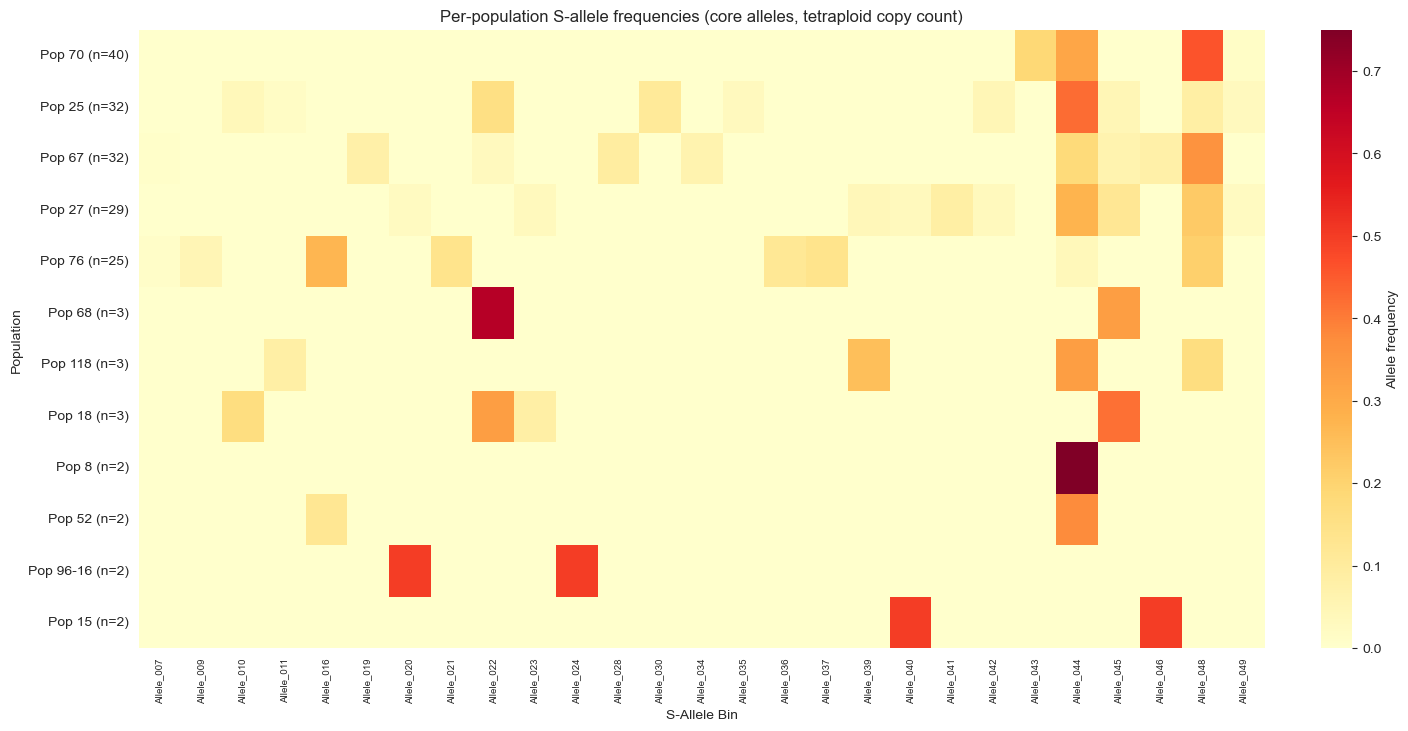

In [15]:
# Heatmap of per-population allele frequencies
fig, ax = plt.subplots(
    figsize=(max(14, len(core_allele_ids) * 0.35), max(4, len(display_pops) * 0.6)),
    layout="constrained"
)
sns.heatmap(
    freq_matrix.astype(float),
    xticklabels=[id_to_name[a] for a in core_allele_ids],
    yticklabels=[f"Pop {p} (n={len(pop_populations[p])})" for p in display_pops],
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Allele frequency"},
)
ax.set_xlabel("S-Allele Bin")
ax.set_ylabel("Population")
ax.set_title("Per-population S-allele frequencies (core alleles, tetraploid copy count)")
ax.tick_params(axis="x", labelsize=7)
plt.show()

## 12. Data Quality Summary

In [16]:
genotype_counts = zygosity_filtered["Genotype"].value_counts()

summary_data = {
    "Metric": [
        "Total individuals in input data",
        "Ingroup individuals with genotypes",
        "Excluded (outgroup + no metadata)",
        "Distinct S-allele bins in matrix",
        "Allele bins detected in ingroup",
        "Singleton alleles (1 individual)",
        "Core alleles (2+ individuals)",
        "Unique populations (Pop)",
        "Major populations (>= 5 individuals)",
        "AAAA (homozygous) genotypes",
        "AABB (2-allele, equal dosage) genotypes",
        "AAAB (2-allele, 3:1 dosage) genotypes",
        "AABC (3-allele, doubled) genotypes",
        "ABCD (4-allele) genotypes",
        "Genotypes requiring count-based resolution (AAAB + AABC)",
        "Genotypes fully deterministic (AAAA + AABB + ABCD)",
    ],
    "Value": [
        len(zygosity_df),
        len(assignments_df),
        len(zygosity_df) - len(assignments_df),
        len(allele_columns),
        len(detected_alleles),
        int(n_singletons),
        len(detected_alleles) - int(n_singletons),
        len(pop_populations),
        int((pop_counts >= 5).sum()),
        int(genotype_counts.get("AAAA", 0)),
        int(genotype_counts.get("AABB", 0)),
        int(genotype_counts.get("AAAB", 0)),
        int(genotype_counts.get("AABC", 0)),
        int(genotype_counts.get("ABCD", 0)),
        int(genotype_counts.get("AAAB", 0)) + int(genotype_counts.get("AABC", 0)),
        int(genotype_counts.get("AAAA", 0)) + int(genotype_counts.get("AABB", 0)) + int(genotype_counts.get("ABCD", 0)),
    ],
}

summary_table = pd.DataFrame(summary_data)
print("Data Quality Summary")
print("=" * 60)
print(summary_table.to_string(index=False))

Data Quality Summary
                                                  Metric  Value
                         Total individuals in input data    189
                      Ingroup individuals with genotypes    189
                       Excluded (outgroup + no metadata)      0
                        Distinct S-allele bins in matrix     47
                         Allele bins detected in ingroup     47
                        Singleton alleles (1 individual)     20
                           Core alleles (2+ individuals)     27
                                Unique populations (Pop)     26
                    Major populations (>= 5 individuals)      5
                             AAAA (homozygous) genotypes    105
                 AABB (2-allele, equal dosage) genotypes     40
                   AAAB (2-allele, 3:1 dosage) genotypes     39
                      AABC (3-allele, doubled) genotypes      5
                               ABCD (4-allele) genotypes      0
Genotypes requiring

## 13. Export Data

Save the assigned population data for downstream notebooks.

| File | Format | Contents |
|---|---|---|
| `data/population.pkl` | Pickle | Full population data dict (genotypes, mappings, pop groups) |
| `data/assigned_genotypes.tsv` | TSV | Human-readable genotype assignments with Pop |


In [17]:
# --- Build export data ---
export_data = {
    "population":       population_genotypes,
    "individual_names": individual_names,
    "allele_pool":      allele_pool,
    "name_to_id":       name_to_id,
    "id_to_name":       id_to_name,
    "pop_map":          pop_map,           # individual -> Pop
    "pop_populations":  pop_populations,   # Pop -> list of genotype tuples
    "pop_individuals":  pop_individuals,   # Pop -> list of individual names
    "core_allele_ids":  core_allele_ids,
    "assignments":      assignments_df.to_dict(orient="records"),
}

# Save pickle
pkl_path = os.path.join(DATA_DIR, "population.pkl")
with open(pkl_path, "wb") as f:
    pickle.dump(export_data, f)
print(f"Saved pickle: {pkl_path}")

# Save human-readable TSV
tsv_rows = []
for i, (_, row) in enumerate(assignments_df.iterrows()):
    g     = row["genotype"]
    int_g = population_genotypes[i]
    tsv_rows.append({
        "Individual":      row["individual"],
        "Pop":             row["pop"],
        "Genotype_Pattern": row["genotype_pattern"],
        "Allele_1":        g[0],
        "Allele_2":        g[1],
        "Allele_3":        g[2],
        "Allele_4":        g[3],
        "ID_1":            int_g[0],
        "ID_2":            int_g[1],
        "ID_3":            int_g[2],
        "ID_4":            int_g[3],
        "Method":          row["method"],
    })

tsv_df = pd.DataFrame(tsv_rows)
tsv_path = os.path.join(DATA_DIR, "assigned_genotypes.tsv")
tsv_df.to_csv(tsv_path, sep="\t", index=False)
print(f"Saved TSV: {tsv_path}")
print(f"\nFirst 10 rows:")
print(tsv_df.head(10).to_string(index=False))

Saved pickle: ../data/population.pkl
Saved TSV: ../data/assigned_genotypes.tsv

First 10 rows:
          Individual   Pop Genotype_Pattern   Allele_1   Allele_2   Allele_3   Allele_4  ID_1  ID_2  ID_3  ID_4           Method
Library001_barcode02    67             AAAB Allele_007 Allele_048 Allele_048 Allele_048     2    40    40    40 heterozygous_3x1
Library001_barcode03 96-16             AAAA Allele_024 Allele_024 Allele_024 Allele_024    17    17    17    17    homozygous_4x
Library001_barcode04 702-3             AAAA Allele_020 Allele_020 Allele_020 Allele_020    13    13    13    13    homozygous_4x
Library001_barcode05 712-5             AAAA Allele_024 Allele_024 Allele_024 Allele_024    17    17    17    17    homozygous_4x
Library001_barcode06    38             AAAA Allele_011 Allele_011 Allele_011 Allele_011     6     6     6     6    homozygous_4x
Library001_barcode07    61             AAAA Allele_048 Allele_048 Allele_048 Allele_048    40    40    40    40    homozygous_4x
Li

In [18]:
def load_population(data_dir=None):
    """Convenience function to load assigned population data.

    Returns
    -------
    dict with keys:
        population        : list[tuple] - assigned genotypes (integer IDs)
        individual_names  : list[str]   - individual names (parallel to population)
        allele_pool       : list[int]   - all allele IDs
        name_to_id        : dict        - allele bin name to integer ID
        id_to_name        : dict        - integer ID to allele bin name
        pop_map           : dict        - individual name to Pop
        pop_populations   : dict        - Pop to list of genotype tuples
        pop_individuals   : dict        - Pop to list of individual names
        core_allele_ids   : list[int]   - alleles present in 2+ individuals
        assignments       : list[dict]  - full assignment details per individual
    """
    if data_dir is None:
        data_dir = os.path.join("..", "data")
    pkl_path = os.path.join(data_dir, "population.pkl")
    with open(pkl_path, "rb") as f:
        return pickle.load(f)


# Verify round-trip
loaded = load_population(DATA_DIR)
assert loaded["population"]  == population_genotypes
assert loaded["allele_pool"] == allele_pool
assert loaded["pop_map"]     == pop_map
print("Round-trip verification passed.")
print(f"  {len(loaded['population'])} genotypes")
print(f"  {len(loaded['allele_pool'])} allele bins")
print(f"  {len(loaded['pop_populations'])} populations")
print(f"\nTo load in other notebooks:")
print("  from pathlib import Path")
print("  import pickle")
print("  data = pickle.load(open(Path('..') / 'data' / 'population.pkl', 'rb'))")

Round-trip verification passed.
  189 genotypes
  47 allele bins
  26 populations

To load in other notebooks:
  from pathlib import Path
  import pickle
  data = pickle.load(open(Path('..') / 'data' / 'population.pkl', 'rb'))
